Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


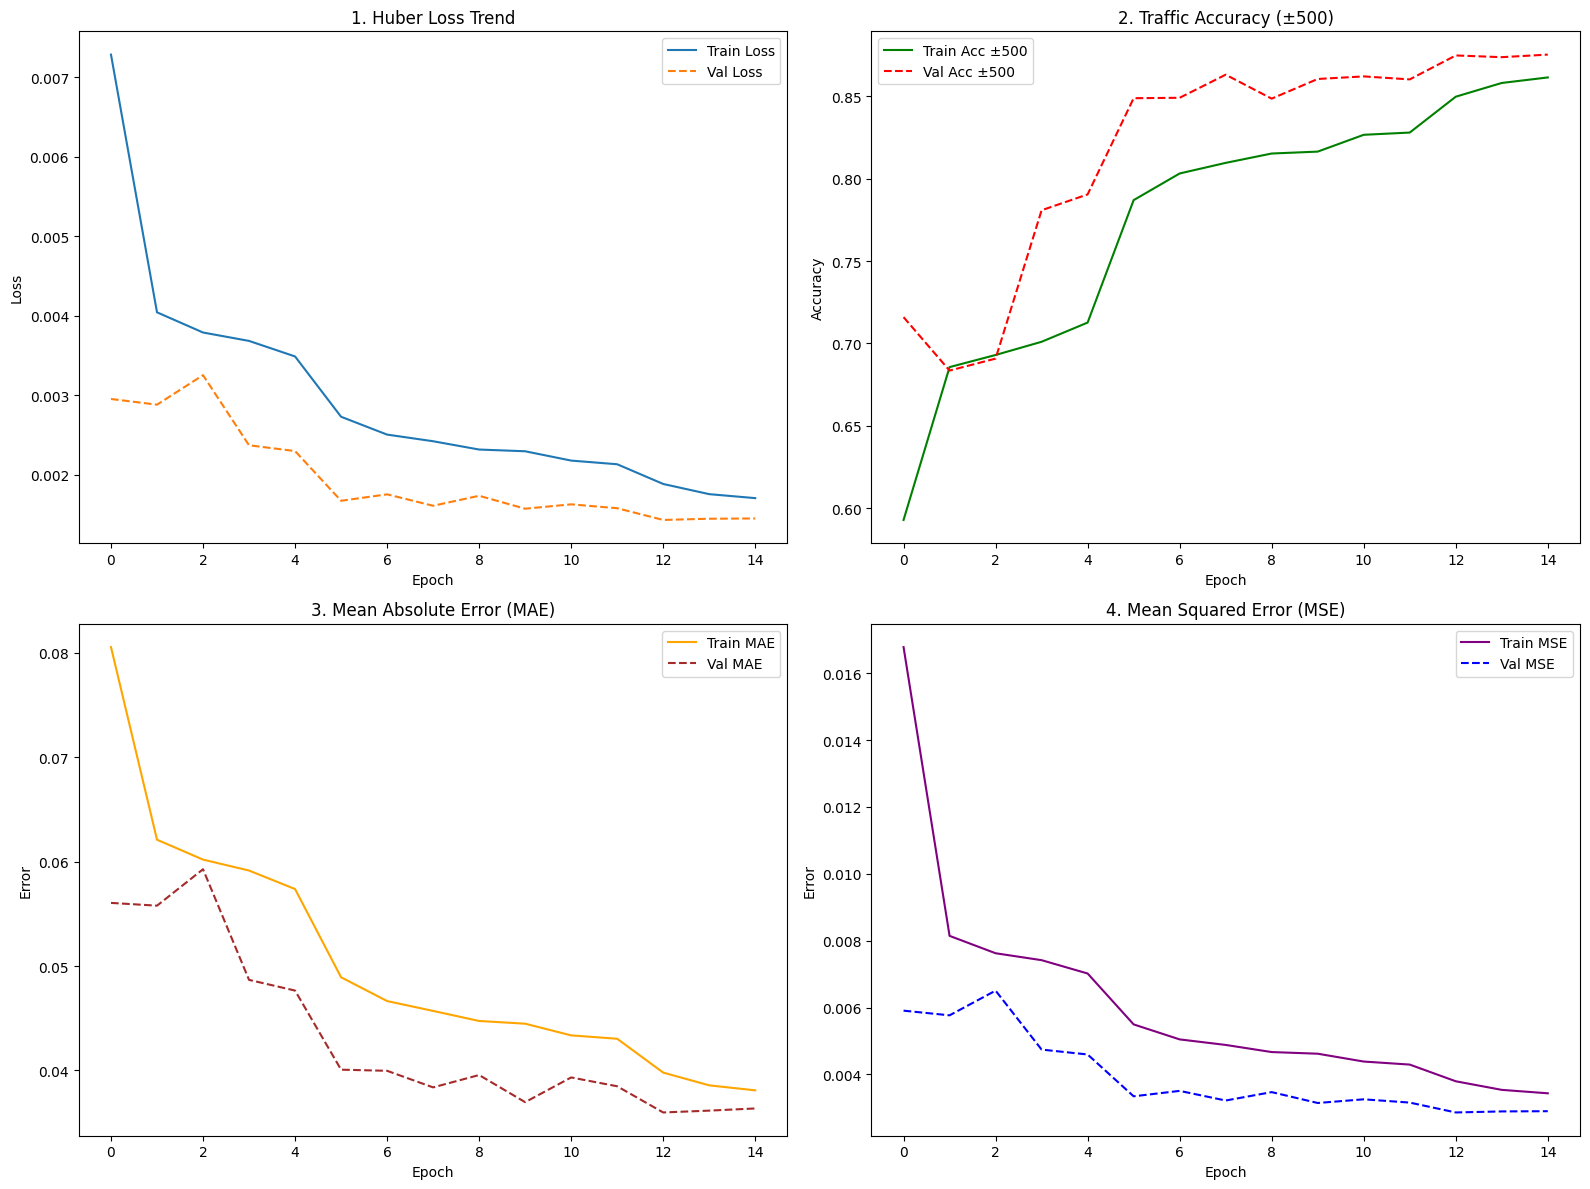

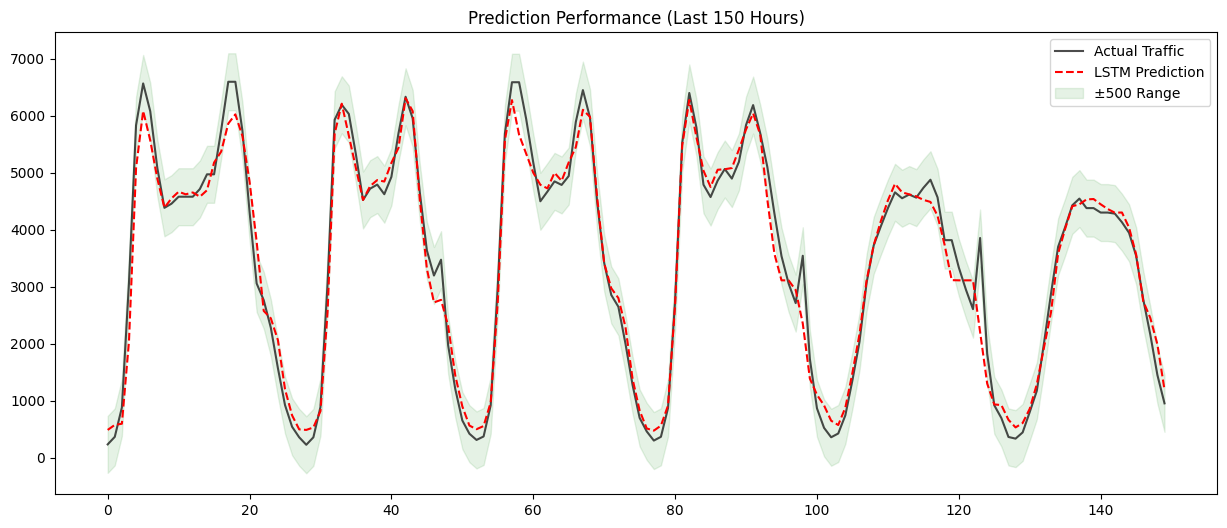


最終測試集 loss: 0.0015
最終測試集 ±500 準確率: 87.55%
最終測試集 MAE: 0.0367
最終測試集 MSE: 0.0030

Final Model Performance (Real Value)
Mean Absolute Error (MAE): 266.90 輛車


In [ ]:
import tensorflow as tf
import joblib
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt


# 連接到雲端硬碟
from google.colab import drive
drive.mount('/content/drive')


# 在載入前，必須先重新定義這個類別，並且加上裝飾器
@tf.keras.utils.register_keras_serializable(package="Custom")
class TrafficAccuracy(tf.keras.metrics.Metric):
    def __init__(self, threshold=500, y_min=0.0, y_max=1.0,
                 name='traffic_acc_500', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = float(threshold)
        self.y_min = float(y_min)
        self.y_max = float(y_max)
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.total = self.add_weight(name='total', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_t_real = y_true * (self.y_max - self.y_min) + self.y_min
        y_p_real = y_pred * (self.y_max - self.y_min) + self.y_min
        is_correct = tf.cast(tf.abs(y_t_real - y_p_real) <= self.threshold,
                             tf.float32)
        self.correct.assign_add(tf.reduce_sum(is_correct))
        self.total.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return tf.math.divide_no_nan(self.correct, self.total)

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({
            'threshold': self.threshold,
            'y_min': self.y_min,
            'y_max': self.y_max
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# 讀取模型與 Scaler和 history
model = tf.keras.models.load_model("/content/drive/MyDrive/dl_github_open_source/model/model.keras")
scaler_X = joblib.load("/content/drive/MyDrive/dl_github_open_source/model/model_scaler_X.pkl")
scaler_y = joblib.load("/content/drive/MyDrive/dl_github_open_source/model/model_scaler_y.pkl")
with open('/content/drive/MyDrive/dl_github_open_source/model/history.json', 'r') as f:
    history = json.load(f)
# 3. data process
from sklearn.preprocessing import MinMaxScaler
TIME_STEPS = 24
df = pd.read_csv("/content/drive/MyDrive/dl_github_open_source/Metro_Interstate_Traffic_Volume.csv")
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time').reset_index(drop=True)
df['hr_sin'] = np.sin(2 * np.pi * df['date_time'].dt.hour / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['date_time'].dt.hour / 24)
df['day_sin'] = np.sin(2 * np.pi * df['date_time'].dt.weekday / 7)
df['day_cos'] = np.cos(2 * np.pi * df['date_time'].dt.weekday / 7)
df['is_peak'] = df['date_time'].dt.hour.isin([7,8,9,16,17,18]).astype(int)
df['rain_1h'] = np.log1p(df['rain_1h'])
df['snow_1h'] = np.log1p(df['snow_1h'])
weather_map = {'Clear': 0, 'Clouds': 1, 'Mist': 1, 'Fog': 1, 'Drizzle': 2, 'Rain': 2, 'Snow': 3, 'Thunderstorm': 3}
df['weather_rank'] = df['weather_main'].map(weather_map).fillna(0)
df['is_holiday'] = (df['holiday'] != 'None').astype(int)
df['lag_1'] = df['traffic_volume'].shift(1).bfill()
df['lag_24'] = df['traffic_volume'].shift(24).bfill()
drop_cols = ['date_time', 'holiday', 'weather_main', 'weather_description', 'traffic_volume']
features = [f for f in df.columns if f not in drop_cols]
target = 'traffic_volume'
scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])
Y_MIN, Y_MAX = float(scaler_y.data_min_[0]), float(scaler_y.data_max_[0])
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)
X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# 8. 預測
y_pred_inv = scaler_y.inverse_transform(model.predict(X_test))
y_test_inv = scaler_y.inverse_transform(y_test)

# 9. 視覺化圖表 (2x2 佈局)
plt.figure(figsize=(16, 12))

# Huber Loss
plt.subplot(2, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss', linestyle='--')
plt.title('1. Huber Loss Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy ±500 (只顯示這個)
plt.subplot(2, 2, 2)
plt.plot(history['traffic_acc_500'], label='Train Acc ±500', color='green')
plt.plot(history['val_traffic_acc_500'], label='Val Acc ±500', color='red', linestyle='--')
plt.title('2. Traffic Accuracy (±500)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# MAE
plt.subplot(2, 2, 3)
plt.plot(history['mae'], label='Train MAE', color='orange')
plt.plot(history['val_mae'], label='Val MAE', color='brown', linestyle='--')
plt.title('3. Mean Absolute Error (MAE)')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()

# MSE
plt.subplot(2, 2, 4)
plt.plot(history['mse'], label='Train MSE', color='purple')
plt.plot(history['val_mse'], label='Val MSE', color='blue', linestyle='--')
plt.title('4. Mean Squared Error (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()

plt.tight_layout()
plt.show()

# 10. 預測對比圖 (單獨一張大圖)
plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[-150:], label='Actual Traffic', color='black', alpha=0.7)
plt.plot(y_pred_inv[-150:], label='LSTM Prediction', color='red', linestyle='--')
plt.fill_between(range(150),
                 y_test_inv[-150:].flatten() - 500,
                 y_test_inv[-150:].flatten() + 500,
                 color='green', alpha=0.1, label='±500 Range')
plt.title('Prediction Performance (Last 150 Hours)')
plt.legend()
plt.show()

# 11. 最終數據輸出
final_results = model.evaluate(X_test, y_test, verbose=0)
print("\n" + "="*40)
print(f"最終測試集 loss: {final_results[0]:.4f}")
print(f"最終測試集 ±500 準確率: {final_results[1]*100:.2f}%")
print(f"最終測試集 MAE: {final_results[2]:.4f}")
print(f"最終測試集 MSE: {final_results[3]:.4f}")
print("="*40)

# 12. real predict mae
y_test_inv = scaler_y.inverse_transform(y_test)

from sklearn.metrics import mean_absolute_error
mae_real = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"\n========================================")
print(f"Final Model Performance (Real Value)")
print(f"Mean Absolute Error (MAE): {mae_real:.2f} 輛車")
print(f"========================================")